In [1]:
# Initial import for necessary libraries
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Section 1
This section completely focus on pre available regression model of sklearn

In [2]:
# Starting with random data sets, n = 4
dataset = np.array([[2, 4, 7, 12], [5, 8, 15, 25]])


In [3]:
# reshaping data to make compatible to work further with regression model
X = dataset[0].reshape(-1, 1)
y = dataset[1].reshape(-1, 1)


In [4]:
# creating an instance of Regression model and fit the intial datasets
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [5]:
print(f"Coefficient(a) = {model.coef_} \n Intercept(m) = {model.intercept_}")

Coefficient(a) = [[2.03964758]] 
 Intercept(m) = [0.50220264]


In [6]:
# Predicting the model output with the same input data we used to train our model
y_pred = model.predict(X)

In [7]:
# Various regression model evaluation parameters
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error = {}".format(mse))
rmse = np.sqrt(mse)
print("Root Mean Squared Error = {}".format(rmse))
r2 = r2_score(y, y_pred)
print("R2 Score = {}".format(r2))
mae = mean_absolute_error(y, y_pred)
print("Mean Absolute Error = {}".format(mae))

Mean Squared Error = 0.1651982378854625
Root Mean Squared Error = 0.4064458609525536
R2 Score = 0.9972088998878909
Mean Absolute Error = 0.3303964757709241


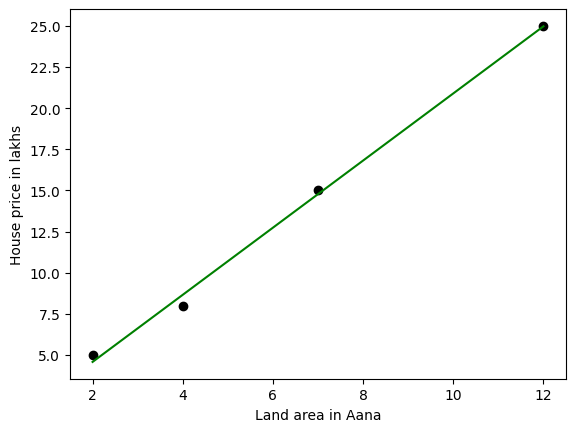

In [8]:
# Final plot of the fitted line and the datasets
plt.scatter(X, y, color = 'black')
plt.xlabel("Land area in Aana")
plt.ylabel("House price in lakhs")
plt.plot(X, y_pred, color = "green")
plt.show()

# Section 2
This section of code only focuses on the part of Batch Gradient Descent with single and mulitple input features.
* No of iterations (Epoch) = 100
* Initial assumption of intecept (b) = 20
* Initial assumption of coefficient (a) = 100
* Learning rate  = 0.1


In [9]:
# Code for Gradient Descent with single input feature
class GradientDescent:

  def __init__(self, epoch, learning_rate, intercept, coefficient):
    self.epoch = epoch
    self.learning_rate = learning_rate
    self.intercept = intercept
    self.coefficient = coefficient

  def fit(self, X, Y):
    n = len(X)
    for i in range(self.epoch):
      # Calculate predictions
      y_pred = self.intercept + self.coefficient * X.ravel()

      # Calculate gradients with division by n
      loss_slope_b = -2 * np.sum(Y.ravel() - y_pred) / n
      loss_slope_a = -2 * np.sum((Y.ravel() - y_pred) * X.ravel()) / n

      # Update parameters
      self.intercept = self.intercept - (self.learning_rate * loss_slope_b)
      self.coefficient = self.coefficient - (self.learning_rate * loss_slope_a)

      plt.scatter(X, Y)
      plt.plot(X, y_pred, color = "red")

    print(f"Intercept (b) = {self.intercept} \n Coefficient (a) = {self.coefficient}")


In [10]:
gd = GradientDescent(10, 0.01, 1, 1)

Intercept (b) = 1.0827047517767978 
 Coefficient (a) = 1.971175611204816


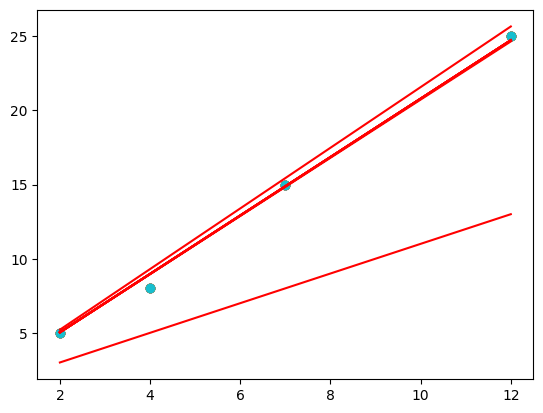

In [11]:
gd.fit(X, y)

In [12]:
# New datasets using make_regression function with 100 instances and 3 input features
X, y = make_regression(n_samples = 100, n_features=3, random_state=42, noise = 1)


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)

In [14]:
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)

LinearRegression()

In [15]:
linear_regressor.coef_

array([28.23258667, 74.99486261, 17.84769134])

In [16]:
linear_regressor.intercept_

np.float64(0.13037594527224794)

In [17]:
linear_regressor.predict(X_test)

array([ 2.67004533e+00,  2.72658265e-01, -6.27089924e+01, -2.19355095e+01,
        5.08647095e+01,  3.12763363e+02,  2.36804593e+01, -7.99018358e+01,
       -1.19390234e+02,  1.35791365e+01,  6.02595157e+01,  2.30495914e+01,
       -4.88038036e+01, -4.92267595e+01,  2.32044097e+01, -3.59597382e+01,
       -3.76126228e+01, -4.46704443e+01, -1.68778066e+01,  5.82942796e+01])

In [18]:
r2 = r2_score(y_true=y_test, y_pred=linear_regressor.predict(X_test))
r2

0.9998271010262919

In [19]:
#Gradient Descent for 3 different input features
class GD_Regressor:
  def __init__(self, epoch, learning_rate, intercept, coefficient_1, coefficient_2, coefficient_3):
    self.epoch = epoch
    self.learning_rate = learning_rate
    self.intercept = intercept
    self.a1 = coefficient_1
    self.a2 = coefficient_2
    self.a3 = coefficient_3

  def fit(self, X, y):
    X1 = np.array([row[0] for row in X]).reshape(-1, 1)
    X2 = np.array([row[1] for row in X]).reshape(-1, 1)
    X3 = np.array([row[2] for row in X]).reshape(-1, 1)

    for i in range(self.epoch):
      y_pred = self.intercept + self.a1 * X1.ravel() + self.a2 * X2.ravel() + self.a3 * X3.ravel()
      loss_slope_intercept = -2 * np.sum(y - y_pred) / len(X)
      loss_slope_a1 = -2 * np.sum((y - y_pred) * X1.ravel()) / len(X1)
      loss_slope_a2 = -2 * np.sum((y - y_pred) * X2.ravel()) / len(X2)
      loss_slope_a3 = -2 * np.sum((y - y_pred) * X3.ravel()) / len(X3)

      self.intercept = self.intercept - self.learning_rate * loss_slope_intercept
      self.a1 = self.a1 - self.learning_rate * loss_slope_a1
      self.a2 = self.a2 - self.learning_rate * loss_slope_a2
      self.a3 = self.a3 - self.learning_rate * loss_slope_a3
    return self.intercept, self.a1, self.a2, self.a3

  def predict(self, X):
    X1 = np.array([row[0] for row in X]).reshape(-1, 1)
    X2 = np.array([row[1] for row in X]).reshape(-1, 1)
    X3 = np.array([row[2] for row in X]).reshape(-1, 1)

    y_pred = self.intercept + self.a1 * X1.ravel() + self.a2 * X2.ravel() + self.a3 * X3.ravel()
    y_pred.reshape(-1, 1)
    return y_pred

In [20]:
gd_regressor = GD_Regressor(100000, 0.01, 2, 20, 50, 10)

In [21]:
gd_regressor.fit(X, y)

(np.float64(0.12492515759115275),
 np.float64(28.214833641067223),
 np.float64(74.95448031089086),
 np.float64(17.84939102289041))

In [22]:
y_pred = gd_regressor.predict(X)

In [23]:
gd_r2_score = r2_score(y, y_pred)
gd_r2_score

0.9998561091982753

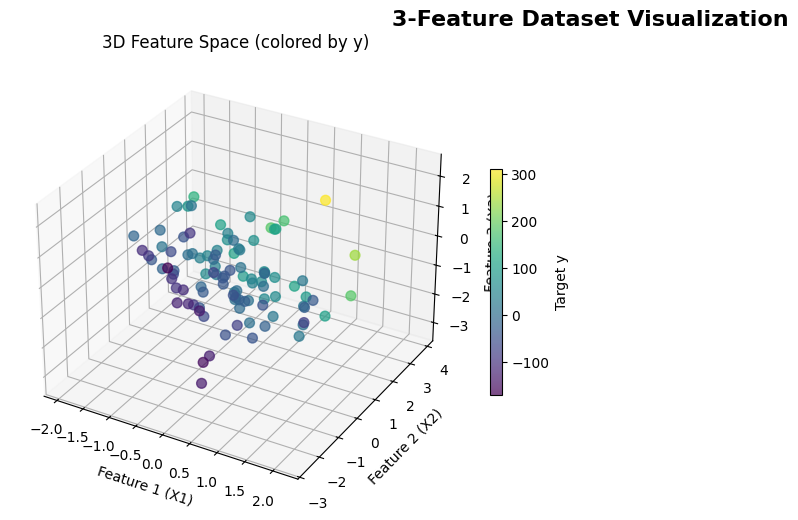

In [24]:
fig = plt.figure(figsize=(12, 10))

# 3D Scatter plot
ax1 = fig.add_subplot(221, projection='3d')
scatter1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', alpha=0.7, s=50)
ax1.set_xlabel('Feature 1 (X1)')
ax1.set_ylabel('Feature 2 (X2)')
ax1.set_zlabel('Feature 3 (X3)')
ax1.set_title('3D Feature Space (colored by y)')
fig.colorbar(scatter1, ax=ax1, shrink=0.5, label='Target y')
plt.suptitle('3-Feature Dataset Visualization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()